## Загрузка данных и библиотек

In [1]:
!pip install causal-ccm

In [3]:
import os
import glob
import pandas as pd
from ccm_pipeline import find_and_plot_optimal_tau, find_and_plot_optimal_E, run_all_ccm

INPUT_DIR = 'ghost_raw_series_logs'
OUTPUT_DIR = 'ccm_ghost_results'

os.makedirs(OUTPUT_DIR, exist_ok=True)

csv_files = glob.glob(os.path.join(INPUT_DIR, '*.csv'))

if not csv_files:
    print(f"В папке {INPUT_DIR} не найдено CSV файлов!")
else:
    print(f"Найдено файлов для анализа: {len(csv_files)}")

Найдено файлов для анализа: 4


## EDM анализ данных


Processing Experiment: Ghost_Const_0.0
[Ghost_Const_0.0] Searching for optimal tau...
[Ghost_Const_0.0] Selected taus: {'val_loss': 2, 'val_accuracy': 2, 'poison_fraction': np.int64(1)}
[Ghost_Const_0.0] Searching for optimal E...
[Ghost_Const_0.0] Global Embedding Dimension E = 6
[Ghost_Const_0.0] Generating CCM plots...
[Ghost_Const_0.0] Running CCM. Global E=6, L_range: 61 steps.


Saved CCM plot to ccm_ghost_results\Ghost_Const_0.0_ccm_poison_causes_loss.pdf


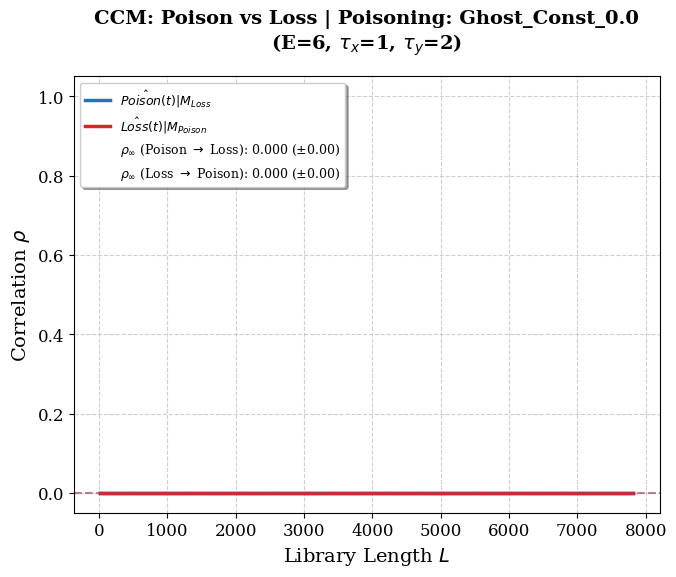

Saved CCM plot to ccm_ghost_results\Ghost_Const_0.0_ccm_poison_causes_acc.pdf


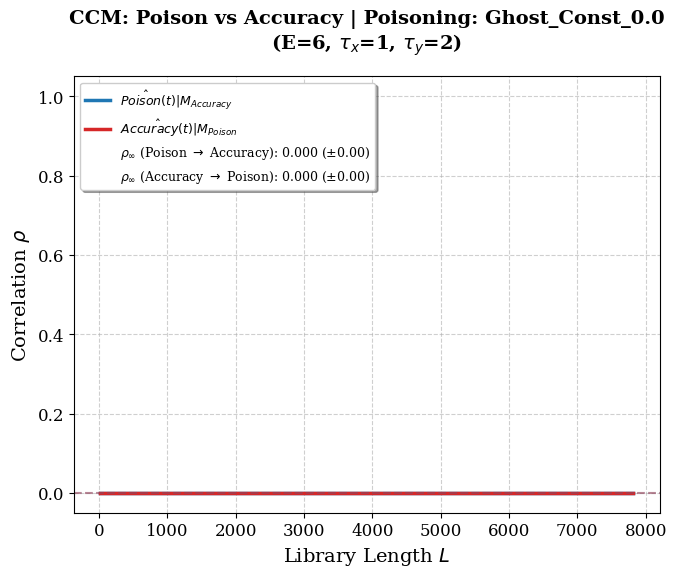

Saved CCM plot to ccm_ghost_results\Ghost_Const_0.0_ccm_loss_and_acc.pdf


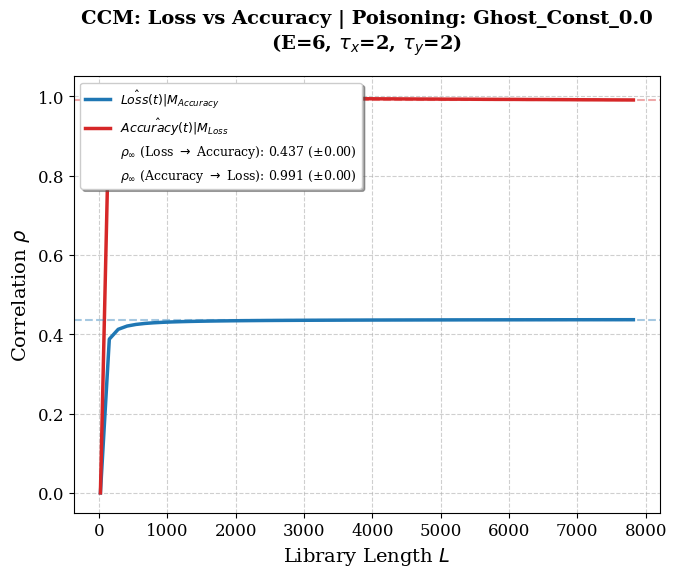


Processing Experiment: Ghost_Const_0.1
[Ghost_Const_0.1] Searching for optimal tau...
[Ghost_Const_0.1] Selected taus: {'val_loss': 2, 'val_accuracy': 2, 'poison_fraction': np.int64(1)}
[Ghost_Const_0.1] Searching for optimal E...
[Ghost_Const_0.1] Global Embedding Dimension E = 6
[Ghost_Const_0.1] Generating CCM plots...
[Ghost_Const_0.1] Running CCM. Global E=6, L_range: 61 steps.


Saved CCM plot to ccm_ghost_results\Ghost_Const_0.1_ccm_poison_causes_loss.pdf


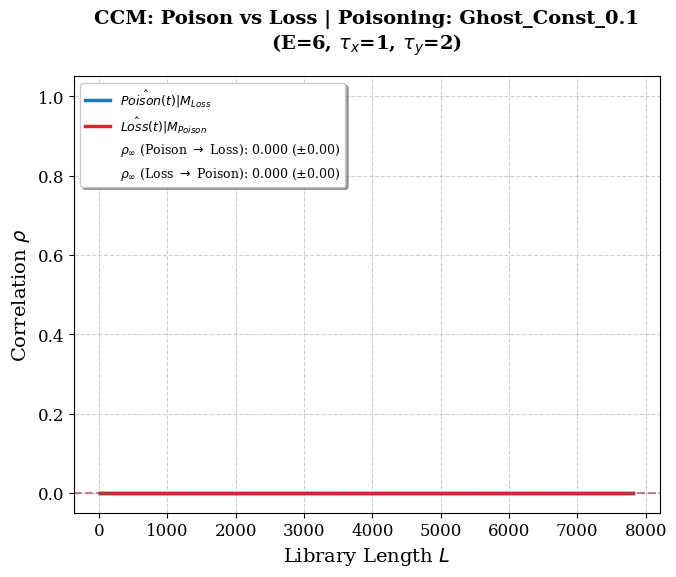

Saved CCM plot to ccm_ghost_results\Ghost_Const_0.1_ccm_poison_causes_acc.pdf


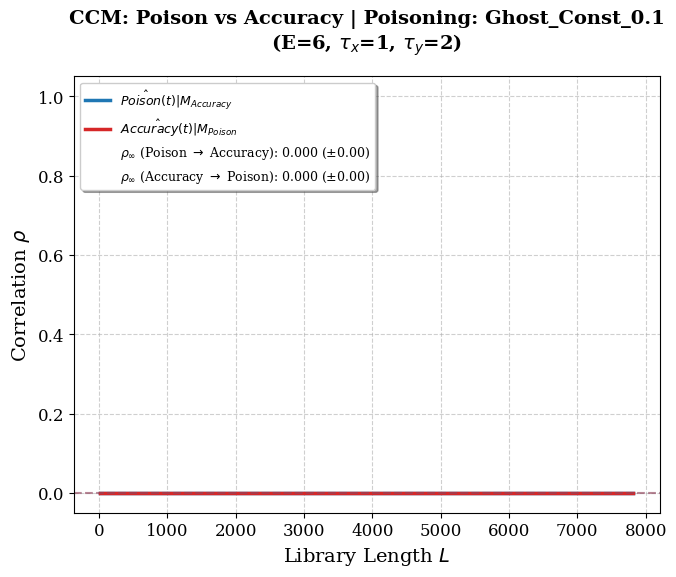

Saved CCM plot to ccm_ghost_results\Ghost_Const_0.1_ccm_loss_and_acc.pdf


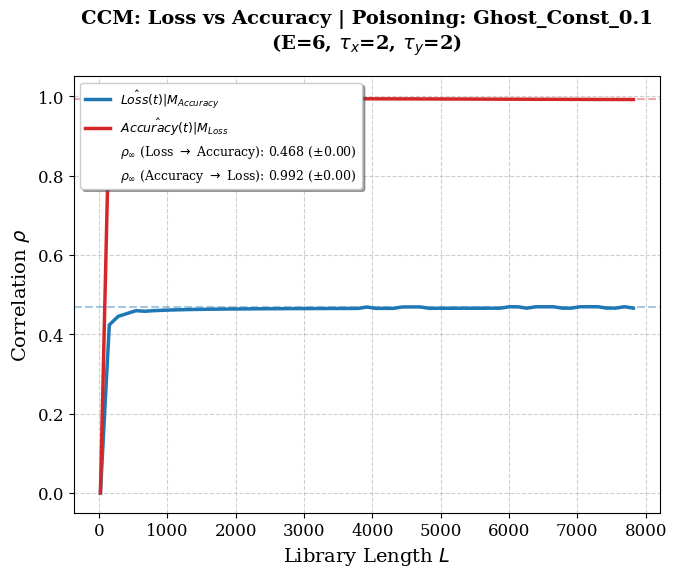


Processing Experiment: Ghost_Normal
[Ghost_Normal] Searching for optimal tau...
[Ghost_Normal] Selected taus: {'val_loss': np.int64(2), 'val_accuracy': 2, 'poison_fraction': 2}
[Ghost_Normal] Searching for optimal E...
[Ghost_Normal] Global Embedding Dimension E = 6
[Ghost_Normal] Generating CCM plots...
[Ghost_Normal] Running CCM. Global E=6, L_range: 61 steps.


Saved CCM plot to ccm_ghost_results\Ghost_Normal_ccm_poison_causes_loss.pdf


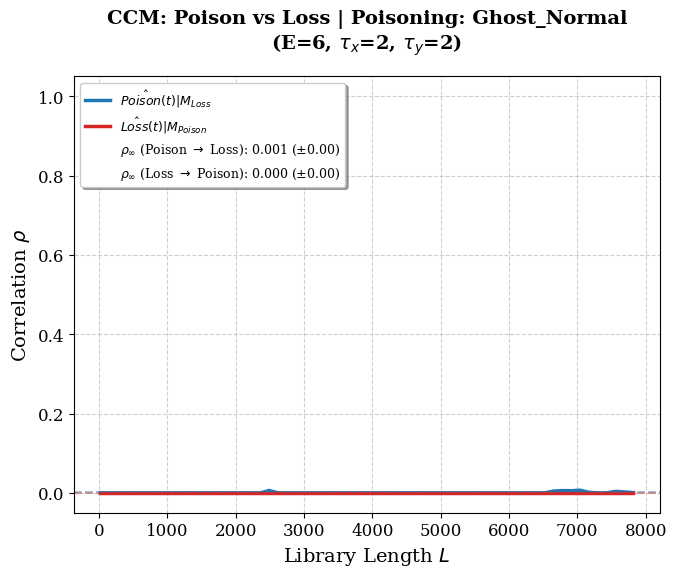

Saved CCM plot to ccm_ghost_results\Ghost_Normal_ccm_poison_causes_acc.pdf


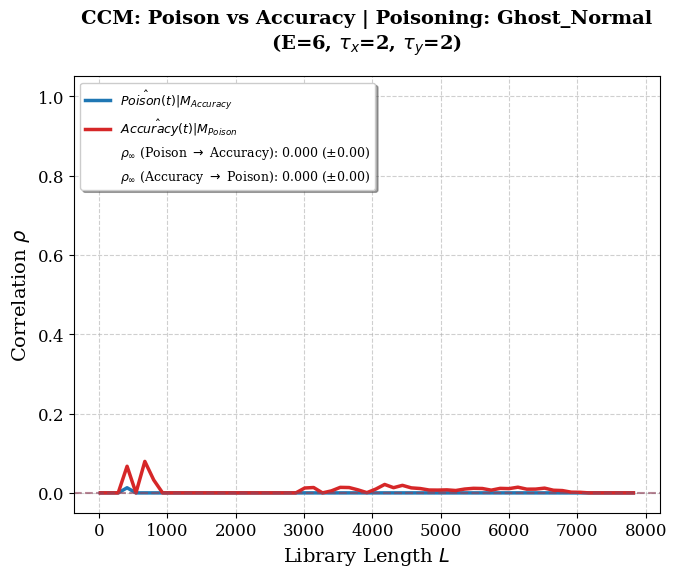

Saved CCM plot to ccm_ghost_results\Ghost_Normal_ccm_loss_and_acc.pdf


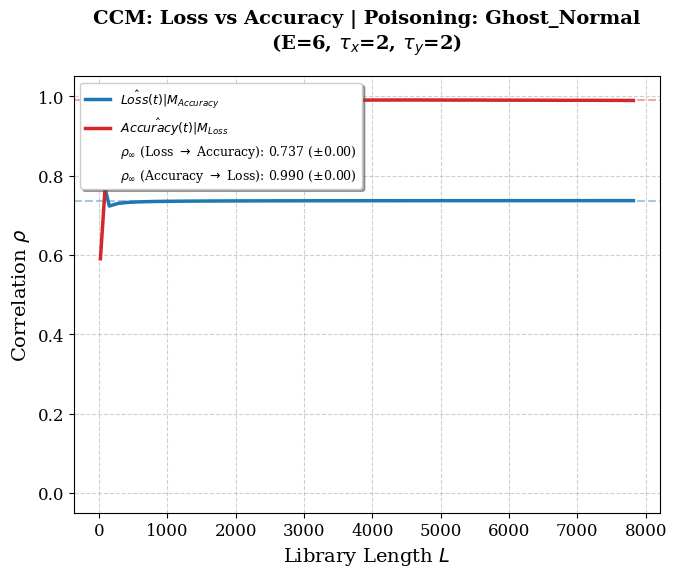


Processing Experiment: Ghost_Uniform
[Ghost_Uniform] Searching for optimal tau...
[Ghost_Uniform] Selected taus: {'val_loss': 2, 'val_accuracy': 2, 'poison_fraction': np.int64(2)}
[Ghost_Uniform] Searching for optimal E...
[Ghost_Uniform] Global Embedding Dimension E = 6
[Ghost_Uniform] Generating CCM plots...
[Ghost_Uniform] Running CCM. Global E=6, L_range: 61 steps.


Saved CCM plot to ccm_ghost_results\Ghost_Uniform_ccm_poison_causes_loss.pdf


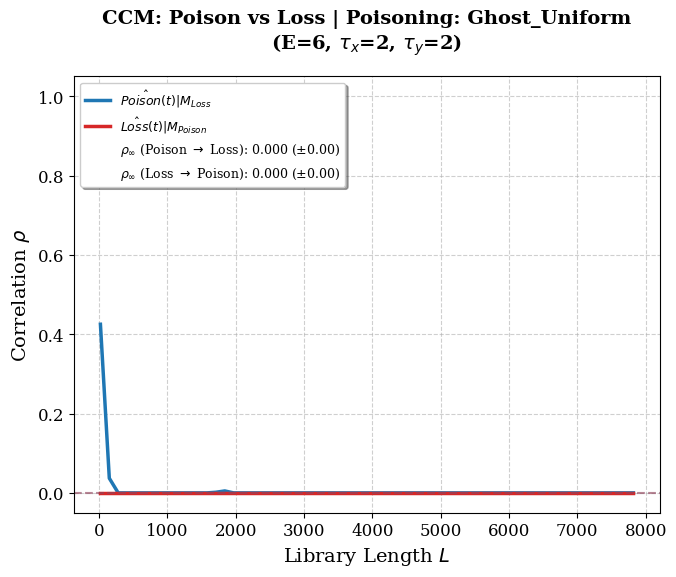

Saved CCM plot to ccm_ghost_results\Ghost_Uniform_ccm_poison_causes_acc.pdf


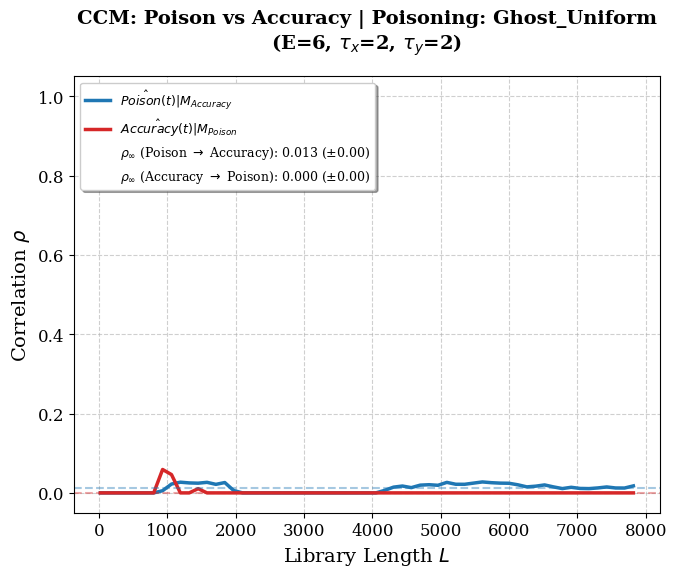

Saved CCM plot to ccm_ghost_results\Ghost_Uniform_ccm_loss_and_acc.pdf


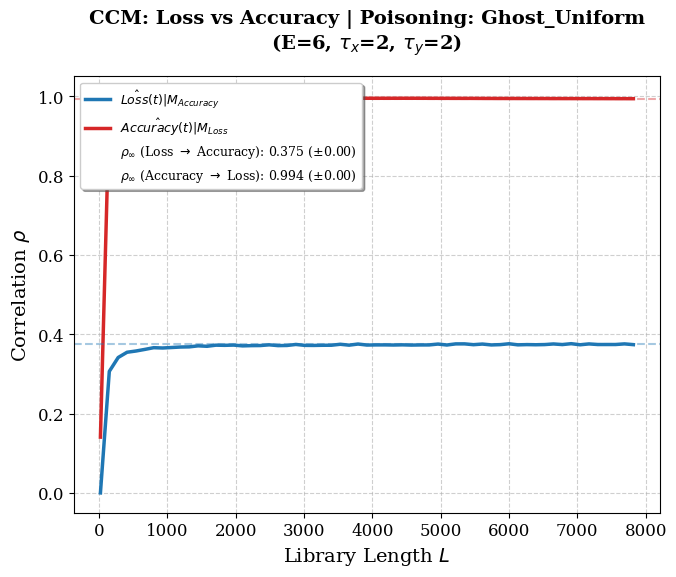


All experiments processed successfully! Check the 'ccm_results' folder.


In [4]:
for file_path in csv_files:

    filename = os.path.basename(file_path)
    exp_name = filename.replace('resnet_cifar_', '').replace('_logs.csv', '').replace('.csv', '')
    
    print(f"\n{'='*50}")
    print(f"Processing Experiment: {exp_name}")
    print(f"{'='*50}")

    df = pd.read_csv(file_path)
    ts_data = {
        'val_loss': df['val_loss'].to_numpy(),
        'val_accuracy': df['val_accuracy'].to_numpy(),
        'poison_fraction': df['poison_fraction'].to_numpy()
    }
    
    print(f"[{exp_name}] Searching for optimal tau...")
    optimal_taus = find_and_plot_optimal_tau(
        ts_data, 
        exp_name=exp_name, 
        out_dir=OUTPUT_DIR, 
        max_tau_search=30,
        strict_max_tau=2
    )
    print(f"[{exp_name}] Selected taus: {optimal_taus}")

    print(f"[{exp_name}] Searching for optimal E...")
    optimal_E_dict, E_global = find_and_plot_optimal_E(
        ts_data, 
        optimal_taus, 
        exp_name=exp_name, 
        out_dir=OUTPUT_DIR,
        max_m_search=15
    )
    print(f"[{exp_name}] Global Embedding Dimension E = {E_global}")

    print(f"[{exp_name}] Generating CCM plots...")
    run_all_ccm(ts_data, optimal_taus, E_global, exp_name, OUTPUT_DIR)

print("\nAll experiments processed successfully! Check the 'ccm_results' folder.")

## EDM анализ данных при $tau = 1$

In [5]:
OUTPUT_DIR = 'ccm_ghost_results_with_tau_one'

os.makedirs(OUTPUT_DIR, exist_ok=True)


Processing Experiment: Ghost_Const_0.0
[Ghost_Const_0.0] Searching for optimal tau...
[Ghost_Const_0.0] Selected taus: {'val_loss': 1, 'val_accuracy': 1, 'poison_fraction': np.int64(1)}
[Ghost_Const_0.0] Searching for optimal E...
[Ghost_Const_0.0] Global Embedding Dimension E = 5
[Ghost_Const_0.0] Generating CCM plots...
[Ghost_Const_0.0] Running CCM. Global E=5, L_range: 61 steps.


Saved CCM plot to ccm_ghost_results_with_tau_one\Ghost_Const_0.0_ccm_poison_causes_loss.pdf


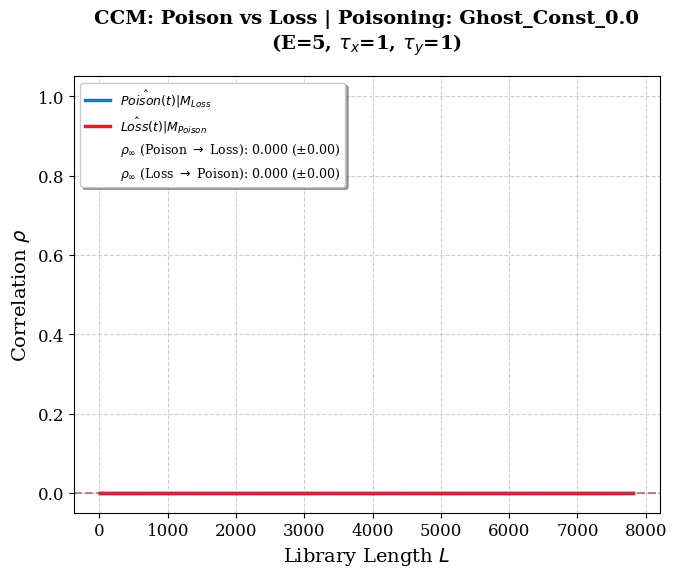

Saved CCM plot to ccm_ghost_results_with_tau_one\Ghost_Const_0.0_ccm_poison_causes_acc.pdf


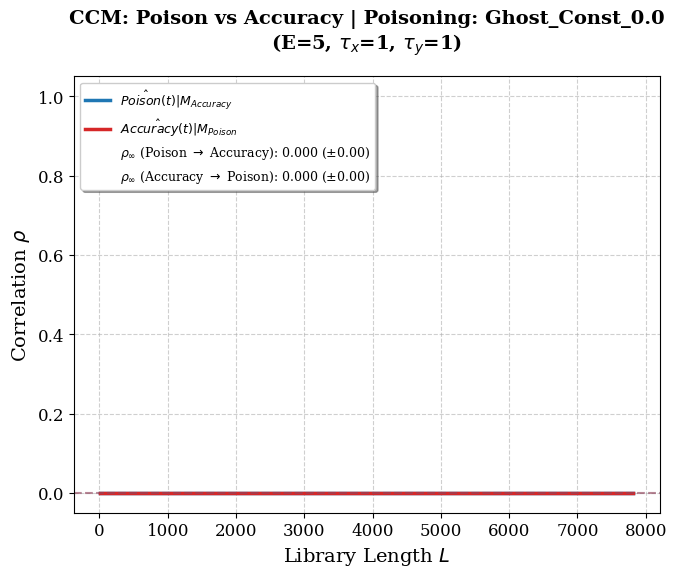

Saved CCM plot to ccm_ghost_results_with_tau_one\Ghost_Const_0.0_ccm_loss_and_acc.pdf


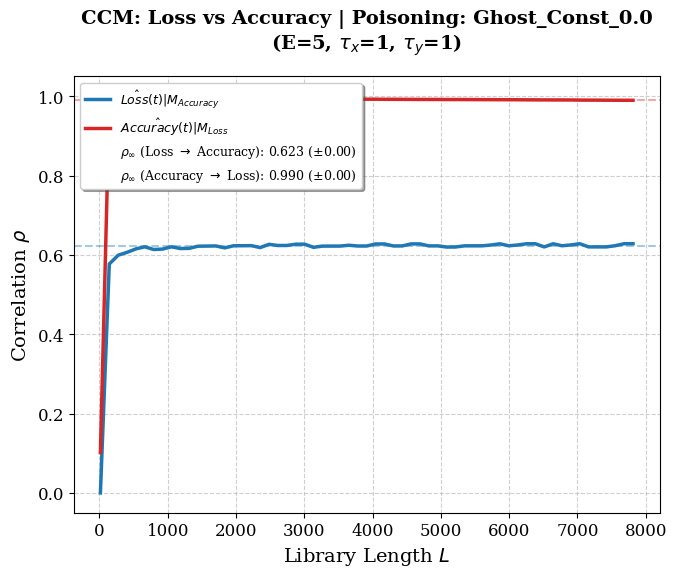


Processing Experiment: Ghost_Const_0.1
[Ghost_Const_0.1] Searching for optimal tau...
[Ghost_Const_0.1] Selected taus: {'val_loss': 1, 'val_accuracy': 1, 'poison_fraction': np.int64(1)}
[Ghost_Const_0.1] Searching for optimal E...
[Ghost_Const_0.1] Global Embedding Dimension E = 5
[Ghost_Const_0.1] Generating CCM plots...
[Ghost_Const_0.1] Running CCM. Global E=5, L_range: 61 steps.


Saved CCM plot to ccm_ghost_results_with_tau_one\Ghost_Const_0.1_ccm_poison_causes_loss.pdf


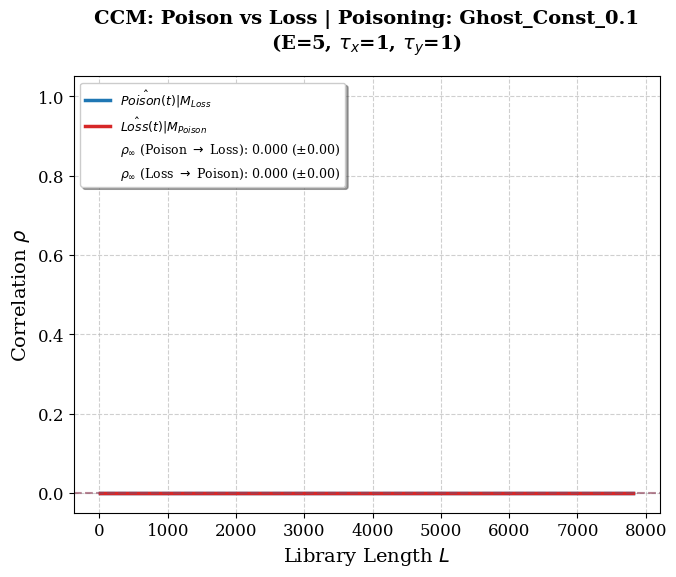

Saved CCM plot to ccm_ghost_results_with_tau_one\Ghost_Const_0.1_ccm_poison_causes_acc.pdf


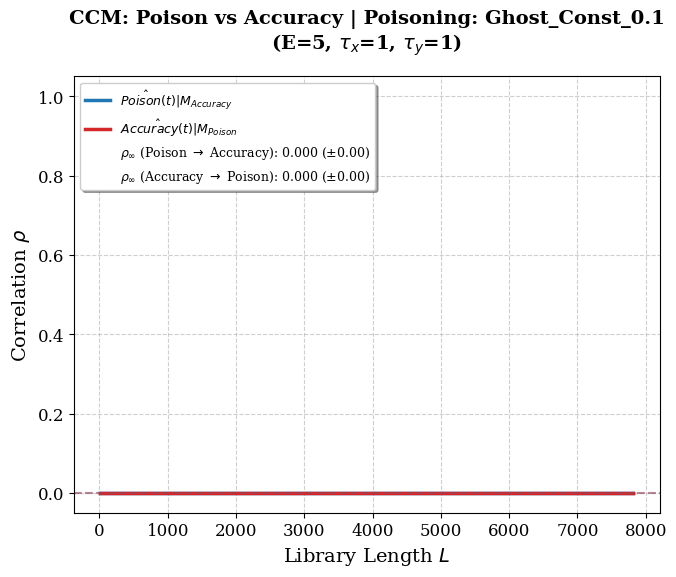

Saved CCM plot to ccm_ghost_results_with_tau_one\Ghost_Const_0.1_ccm_loss_and_acc.pdf


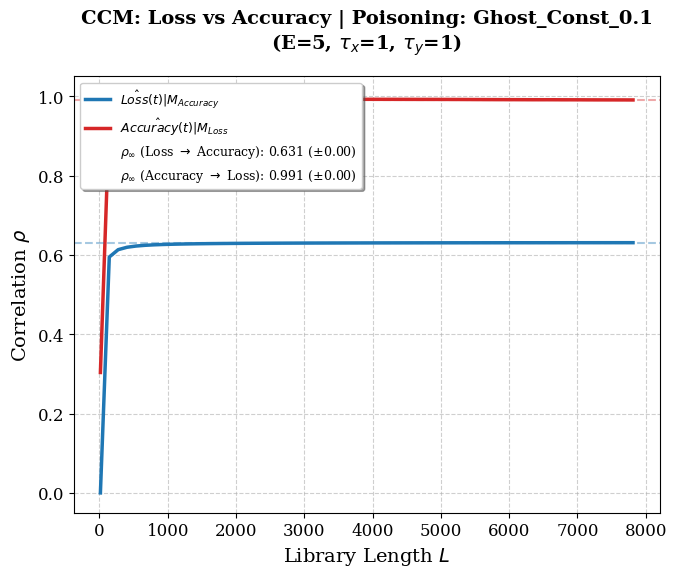


Processing Experiment: Ghost_Normal
[Ghost_Normal] Searching for optimal tau...
[Ghost_Normal] Selected taus: {'val_loss': 1, 'val_accuracy': 1, 'poison_fraction': 1}
[Ghost_Normal] Searching for optimal E...
[Ghost_Normal] Global Embedding Dimension E = 5
[Ghost_Normal] Generating CCM plots...
[Ghost_Normal] Running CCM. Global E=5, L_range: 61 steps.


Saved CCM plot to ccm_ghost_results_with_tau_one\Ghost_Normal_ccm_poison_causes_loss.pdf


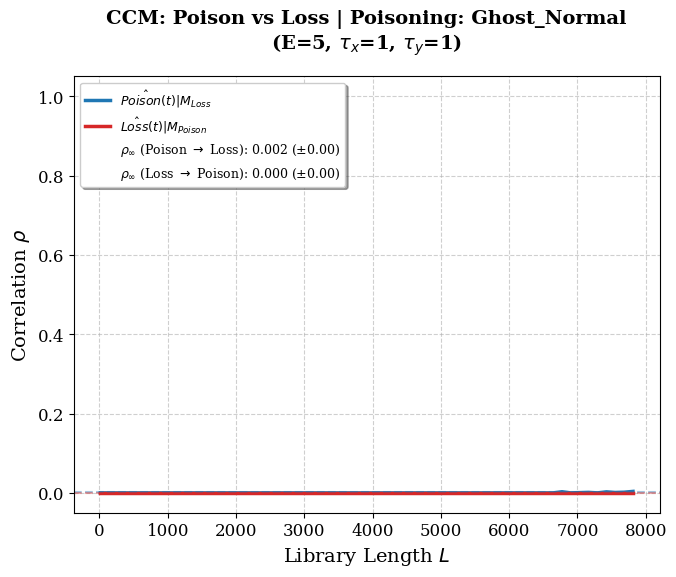

Saved CCM plot to ccm_ghost_results_with_tau_one\Ghost_Normal_ccm_poison_causes_acc.pdf


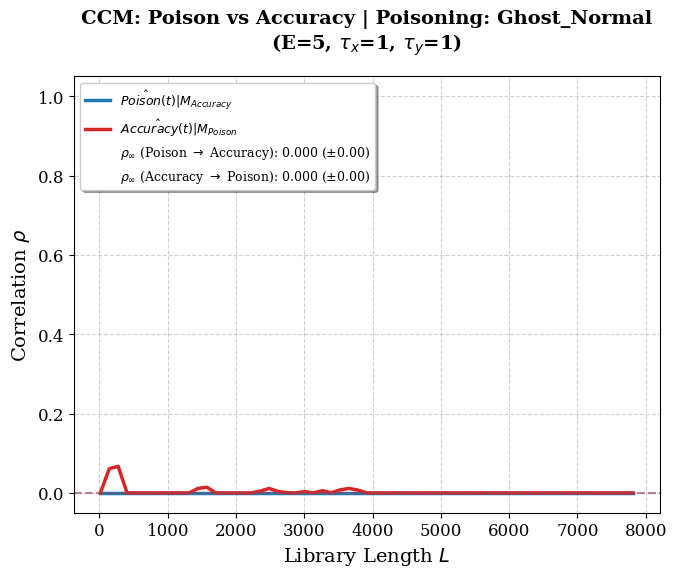

Saved CCM plot to ccm_ghost_results_with_tau_one\Ghost_Normal_ccm_loss_and_acc.pdf


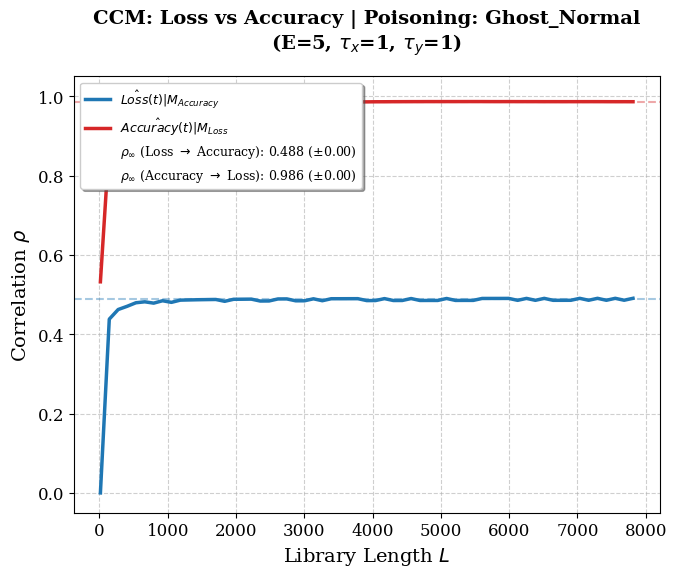


Processing Experiment: Ghost_Uniform
[Ghost_Uniform] Searching for optimal tau...
[Ghost_Uniform] Selected taus: {'val_loss': 1, 'val_accuracy': 1, 'poison_fraction': 1}
[Ghost_Uniform] Searching for optimal E...
[Ghost_Uniform] Global Embedding Dimension E = 5
[Ghost_Uniform] Generating CCM plots...
[Ghost_Uniform] Running CCM. Global E=5, L_range: 61 steps.


Saved CCM plot to ccm_ghost_results_with_tau_one\Ghost_Uniform_ccm_poison_causes_loss.pdf


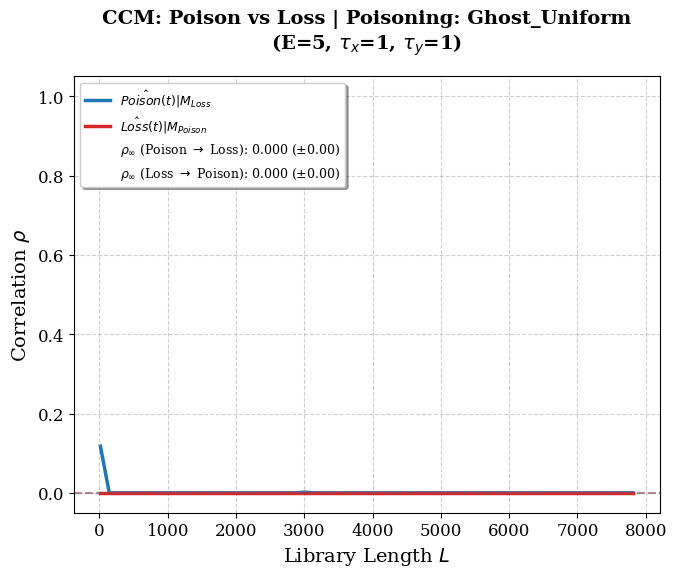

Saved CCM plot to ccm_ghost_results_with_tau_one\Ghost_Uniform_ccm_poison_causes_acc.pdf


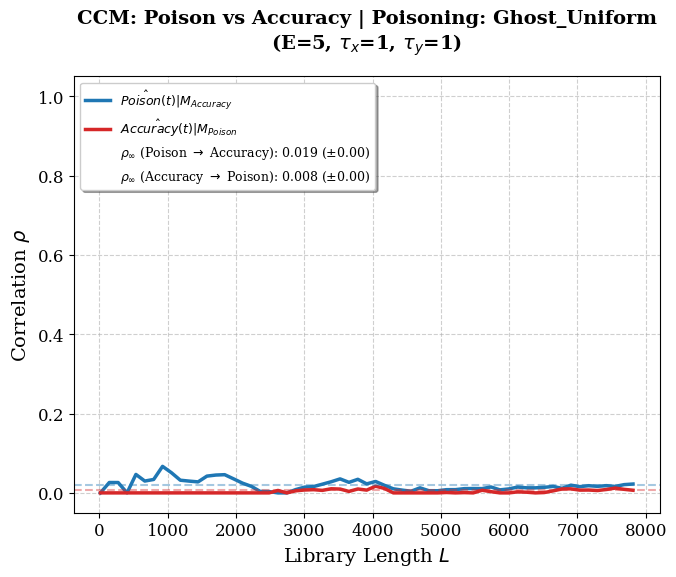

Saved CCM plot to ccm_ghost_results_with_tau_one\Ghost_Uniform_ccm_loss_and_acc.pdf


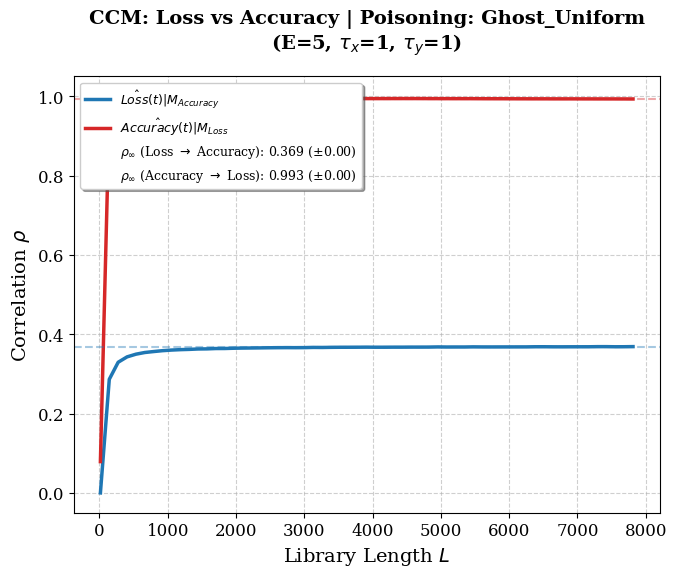


All experiments processed successfully! Check the 'ccm_results_with_tau_one' folder.


In [6]:
for file_path in csv_files:

    filename = os.path.basename(file_path)
    exp_name = filename.replace('resnet_cifar_', '').replace('_logs.csv', '').replace('.csv', '')
    
    print(f"\n{'='*50}")
    print(f"Processing Experiment: {exp_name}")
    print(f"{'='*50}")

    df = pd.read_csv(file_path)
    ts_data = {
        'val_loss': df['val_loss'].to_numpy(),
        'val_accuracy': df['val_accuracy'].to_numpy(),
        'poison_fraction': df['poison_fraction'].to_numpy()
    }
    
    print(f"[{exp_name}] Searching for optimal tau...")
    optimal_taus = find_and_plot_optimal_tau(
        ts_data, 
        exp_name=exp_name, 
        out_dir=OUTPUT_DIR, 
        max_tau_search=30,
        strict_max_tau=1
    )
    print(f"[{exp_name}] Selected taus: {optimal_taus}")

    print(f"[{exp_name}] Searching for optimal E...")
    optimal_E_dict, E_global = find_and_plot_optimal_E(
        ts_data, 
        optimal_taus, 
        exp_name=exp_name, 
        out_dir=OUTPUT_DIR,
        max_m_search=15
    )
    print(f"[{exp_name}] Global Embedding Dimension E = {E_global}")

    print(f"[{exp_name}] Generating CCM plots...")
    run_all_ccm(ts_data, optimal_taus, E_global, exp_name, OUTPUT_DIR)

print("\nAll experiments processed successfully! Check the 'ccm_results_with_tau_one' folder.")